# Figure S11D-F. Benchmarking CRISPR spacer host prediction

In [25]:
### load packages
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

plt.rcParams.update({'font.size': 14})

### Benchmark using UHGV HQ genomes

In [26]:
### Load UHGV metadata
hq_votus = (
    pl.read_csv('../figure_s6/votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'crispr_total_connections', 'crispr_host_agreement', 'crispr_host_lineage_gtdb_r207'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns(pl.col('crispr_total_connections').cast(pl.Float64))
        .with_columns(pl.col('crispr_host_agreement').cast(pl.Float64))
        .with_columns([
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum')
        ])
)
print("Total UHGV HQ vOTUs:", hq_votus['uhgv_genome'].n_unique())
print("Number of UHGV HQ vOTUs with predicted hosts from kmer method:", hq_votus.filter(pl.col('crispr_total_connections') > 0)['uhgv_genome'].n_unique())
print("Number with species-level assignments:", hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
print("Number with genus-level assignments:", hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
print("Number with family-level assignments:", hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())
print("Number with order-level assignments:", hq_votus.filter(pl.col('host_order').is_not_null())['uhgv_genome'].n_unique())
print("Number with class-level assignments:", hq_votus.filter(pl.col('host_class').is_not_null())['uhgv_genome'].n_unique())
print("Number with phylum-level assignments:", hq_votus.filter(pl.col('host_phylum').is_not_null())['uhgv_genome'].n_unique())

Total UHGV HQ vOTUs: 57514
Number of UHGV HQ vOTUs with predicted hosts from kmer method: 51391
Number with species-level assignments: 26250
Number with genus-level assignments: 43084
Number with family-level assignments: 48314
Number with order-level assignments: 49669
Number with class-level assignments: 50370
Number with phylum-level assignments: 51391


In [27]:
### Load UHVDB host predictions
# load mapping file
mapping = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11_outputs/rename/hq_hc_viruses/hq_hc_viruses.id_mapping.tsv.gz', separator='\t', ignore_errors=True, has_header=False)
    .with_columns([
        pl.col('column_1').str.replace(r'\|provirus.*', '')
    ])
)

# join with host predictions
uhvdb_host_predictions = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11/uhvdb/crisprhost/crisprhost.tsv.gz', separator='\t', ignore_errors=True)
        .join(mapping, left_on='Target id', right_on='column_2', how='inner')
)
uhvdb_host_predictions.head(2)

Target id,total_connections,max_connections,top_taxonomy,agreement,rank,column_1
str,i64,i64,str,f64,str,str
"""UHVDB-1957""",167,156,"""Prevotella sp003447235""",0.934132,"""species""","""UHGV-0004570"""
"""UHVDB-19865""",17,17,"""Odoribacter splanchnicus""",1.0,"""species""","""UHGV-0043616"""


In [28]:
### Calculate agreement between new CRISPR assignments and UHGV with different consensus thresholds
recalls = []
precisions = []
f1s = []
num_hits = []
props = []
ranks = []
fps = []
agreements = []

for rank in ['species', 'genus', 'family']:#, 'phylum']:#, 'order', 'class', 'phylum']:
    for agreement in [0.7, 0.8, 0.9, 0.95]:
        uhgv_new = (
            uhvdb_host_predictions
                # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
                # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
                # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
                # .with_columns(pl.col('phylum').str.split('_').list[0])
                # # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
                # # .with_columns(pl.col('class').str.split('_').list[0])
                .filter(pl.col('rank') == rank)
                .filter(pl.col('agreement') >= agreement)
        )

        # identify UHVDB agreement with UHGV phist assignments
        uhgv_uhvdb_join = (
            uhgv_new
                .join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='left')
        )
        tp = uhgv_uhvdb_join.filter(pl.col('top_taxonomy') == pl.col(f'host_{rank}')).height
        fp = uhgv_uhvdb_join.filter((pl.col('top_taxonomy') != pl.col(f'host_{rank}')) & (~pl.col('top_taxonomy').is_null())).height
        fn = uhgv_uhvdb_join.filter(pl.col('top_taxonomy').is_null()).height
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        props.append(uhgv_new.height / hq_votus['uhgv_genome'].n_unique())
        ranks.append(rank)
        agreements.append(agreement)

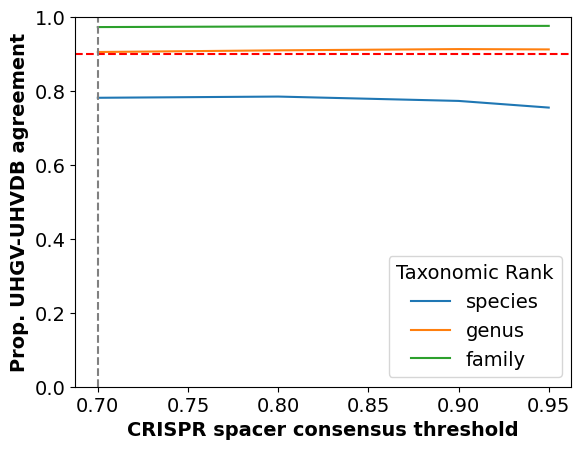

In [29]:
### Plot agreement between new CRISPR assignments and UHGV with different consensus thresholds
precision_df = pl.DataFrame({
    'rank': ranks,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props,
    'agreement_threshold': agreements,
})

# plot results as a seaborn boxplot
sns.lineplot(data=precision_df, x='agreement_threshold', y='precision', hue='rank')
plt.xlabel('CRISPR spacer consensus threshold', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=0.7, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

In [30]:
### Calculate agreement between new CRISPR assignments and UHGV with different consensus thresholds
recalls = []
precisions = []
f1s = []
num_hits = []
props = []
ranks = []
fps = []
agreements = []

for rank in ['species', 'genus', 'family']:#, 'phylum']:#, 'order', 'class', 'phylum']:
    for agreement in [0.7, 0.8, 0.9, 0.95]:
        uhgv_new = (
            uhvdb_host_predictions
                # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
                # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
                # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
                # .with_columns(pl.col('phylum').str.split('_').list[0])
                # # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
                # # .with_columns(pl.col('class').str.split('_').list[0])
                .filter(pl.col('rank') == rank)
                .filter(pl.col('agreement') >= agreement)
        )

        # identify UHVDB agreement with UHGV phist assignments
        uhgv_uhvdb_join = (
            uhgv_new
                .join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='left')
        )

        for num_hit in [1, 2, 3, 5, 10, 20, 50]:
            tp = uhgv_uhvdb_join.filter(pl.col('top_taxonomy') == pl.col(f'host_{rank}')).filter(pl.col('total_connections') >= num_hit).height
            fp = uhgv_uhvdb_join.filter((pl.col('top_taxonomy') != pl.col(f'host_{rank}')) & (~pl.col('top_taxonomy').is_null())).filter(pl.col('total_connections') >= num_hit).height
            fn = uhgv_uhvdb_join.filter(pl.col('top_taxonomy').is_null()).height
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            recalls.append(recall)
            precisions.append(precision)
            f1s.append(f1)
            props.append(uhgv_new.height / hq_votus['uhgv_genome'].n_unique())
            ranks.append(rank)
            num_hits.append(num_hit)
            agreements.append(agreement)

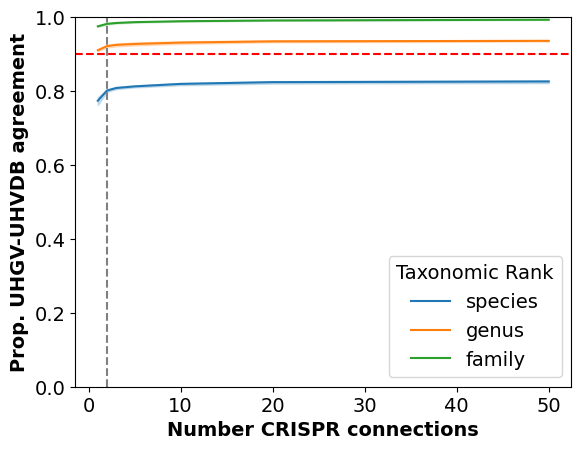

In [31]:
### Plot agreement between new CRISPR assignments and UHGV with different spacer hit count thresholds
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_hits': num_hits,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn boxplot
sns.lineplot(data=precision_df, x='num_hits', y='precision', hue='rank')
plt.xlabel('Number CRISPR connections', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=2, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

In [32]:
### Identify number of HQ vOTUs run through both methods
both_methods = set(
    mapping.join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='inner')
        ['column_1']
)
print("Number of HQ vOTUs run through both methods:", len(both_methods))

Number of HQ vOTUs run through both methods: 51339


In [33]:
### Calculate proportion of UHGV assigned with different spacer hit count thresholds for new and old methods
props = []
methods = []
num_hits = []
ranks = []

for rank in ['species', 'genus', 'family']:
    for num_hit in [1, 2, 3, 5, 10, 20, 50]:
        uhgv_new = (
            uhvdb_host_predictions
                .filter(pl.col('column_1').is_in(both_methods))
                # .with_columns(pl.col('phylum').str.replace('Pseudomonadota', 'Proteobacteria'))
                # .with_columns(pl.col('phylum').str.replace('Bacillota', 'Firmicutes'))
                # .with_columns(pl.col('phylum').str.replace('Actinomycetota', 'Actinobacteriota'))
                # .with_columns(pl.col('phylum').str.split('_').list[0])
                # # .with_columns(pl.col('class').str.replace('Actinomycetes', 'Actinomycetia'))
                # # .with_columns(pl.col('class').str.split('_').list[0])
                .filter(pl.col('rank') == rank)
                .filter(pl.col('agreement') >= 0.7)
                .filter(pl.col('total_connections') >= num_hit)
                
        )
        props.append(uhgv_new.height / hq_votus.filter(pl.col('uhgv_genome').is_in(both_methods))['uhgv_genome'].n_unique())
        methods.append('UHVDB')
        num_hits.append(num_hit)
        ranks.append(rank)

        uhgv_old = (
            hq_votus
                .filter(pl.col('uhgv_genome').is_in(both_methods))
                .filter(pl.col(f'host_{rank}').is_not_null())
                .filter(pl.col('crispr_host_agreement') >= 0.7)
                .filter(pl.col('crispr_total_connections') >= num_hit)
                .unique('uhgv_genome')
        )

        props.append(uhgv_old.height / hq_votus.filter(pl.col('uhgv_genome').is_in(both_methods))['uhgv_genome'].n_unique())
        methods.append('UHGV')
        num_hits.append(num_hit)
        ranks.append(rank)

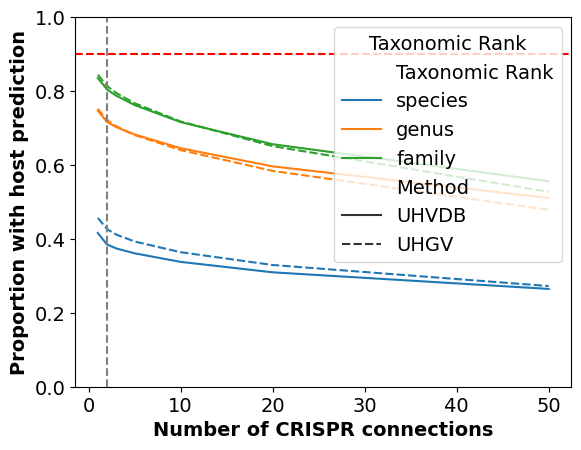

In [34]:
### Plot annotaiton rate comparison between new and old methods
annotation_rate_df = pl.DataFrame({
    'Taxonomic Rank': ranks,
    'num_hits': num_hits,
    'props': props,
    'Method': methods
})

# plot results as a seaborn boxplot
sns.lineplot(data=annotation_rate_df, x='num_hits', y='props', hue='Taxonomic Rank', style='Method')
plt.xlabel('Number of CRISPR connections', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion with host prediction', fontdict={'fontweight': 'bold'})
# horizontal line at y=0.9
# move legend to bottom right
plt.legend(title='Taxonomic Rank', loc='upper right') 
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=2, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()